# Coincall BTCUSD Futures — Trades Capture Analysis

**Data:** `btcusd_trades_20260614_21.parquet`  
**Capture window:** 2026-06-14 21:20 → 22:00 UTC (~40 minutes)  
**Source:** Coincall REST API `/open/futures/trade/lasttrade/v1/BTCUSD`, polled every 10 s  

Sections: Data Overview · Price Timeline · Trade Sizes · Cumulative Volume & OFI · Rolling OFI · Inter-trade Gaps · Activity Rate · Capture Latency · Price Impact · Summary

In [12]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")

DATA    = "/Volumes/SEAGATE/Crypto/Coincall_OB/futures_ws/btcusd_trades_20260614_22.parquet"
FIG_DIR = pathlib.Path("figures"); FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
BUY_C  = "#2ecc71"
SELL_C = "#e74c3c"
NEU_C  = "steelblue"


## 1 · Data Overview

In [13]:
df = pd.read_parquet(DATA)
df = df.sort_values("time").reset_index(drop=True)

df["ts"]           = pd.to_datetime(df["time"],       unit="ms", utc=True)
df["recv_ts"]      = pd.to_datetime(df["recv_ts_ms"], unit="ms", utc=True)
df["side_label"]   = df["trade_side"].map({1: "BUY", 2: "SELL"})
df["signed_qty"]   = df.apply(lambda r: r["qty"] if r["trade_side"] == 1 else -r["qty"], axis=1)
df["staleness_ms"] = (df["recv_ts_ms"] - df["time"]).clip(lower=0)
df["dt_ms"]        = df["time"].diff()

n_trades  = len(df)
n_batches = df["recv_ts_ms"].nunique()
t_start   = df["ts"].iloc[0]
t_end     = df["ts"].iloc[-1]
span_min  = (t_end - t_start).total_seconds() / 60
price_lo  = df["price"].min()
price_hi  = df["price"].max()
n_buy     = (df["trade_side"] == 1).sum()
n_sell    = (df["trade_side"] == 2).sum()

print(f"Trades       : {n_trades}")
print(f"Poll batches : {n_batches}")
print(f"Span         : {t_start.strftime('%H:%M:%S')} → {t_end.strftime('%H:%M:%S')} UTC  ({span_min:.1f} min)")
print(f"Price range  : ${price_lo:,.1f} → ${price_hi:,.1f}  (Δ ${price_hi - price_lo:,.1f})")
print(f"BUY / SELL   : {n_buy} / {n_sell}  ({n_buy/n_trades*100:.1f}% / {n_sell/n_trades*100:.1f}%)")
print(f"Qty (median) : {df['qty'].median():.4f} BTC   (max: {df['qty'].max():.4f} BTC)")
print()
print(df[["ts", "price", "qty", "side_label", "staleness_ms"]].head(10).to_string(index=False))


Trades       : 3352
Poll batches : 359
Span         : 22:00:10 → 23:00:01 UTC  (59.9 min)
Price range  : $64,979.6 → $65,655.6  (Δ $676.0)
BUY / SELL   : 1635 / 1717  (48.8% / 51.2%)
Qty (median) : 0.0009 BTC   (max: 0.7200 BTC)

                              ts   price    qty side_label  staleness_ms
2026-06-14 22:00:10.157000+00:00 65419.8 0.0009        BUY         10425
2026-06-14 22:00:11.092000+00:00 65418.7 0.0010       SELL          9490
2026-06-14 22:00:12.926000+00:00 65401.0 0.0009        BUY          7656
2026-06-14 22:00:13.743000+00:00 65394.1 0.0010        BUY          6839
2026-06-14 22:00:14.535000+00:00 65394.5 0.0010        BUY          6047
2026-06-14 22:00:16.219000+00:00 65380.4 0.0010       SELL          4363
2026-06-14 22:00:16.552000+00:00 65388.3 0.0010        BUY          4030
2026-06-14 22:00:17.083000+00:00 65386.3 0.0009       SELL          3499
2026-06-14 22:00:18.340000+00:00 65395.3 0.0009        BUY          2242
2026-06-14 22:00:19.452000+00:00 65397.3

## 2 · Price Timeline

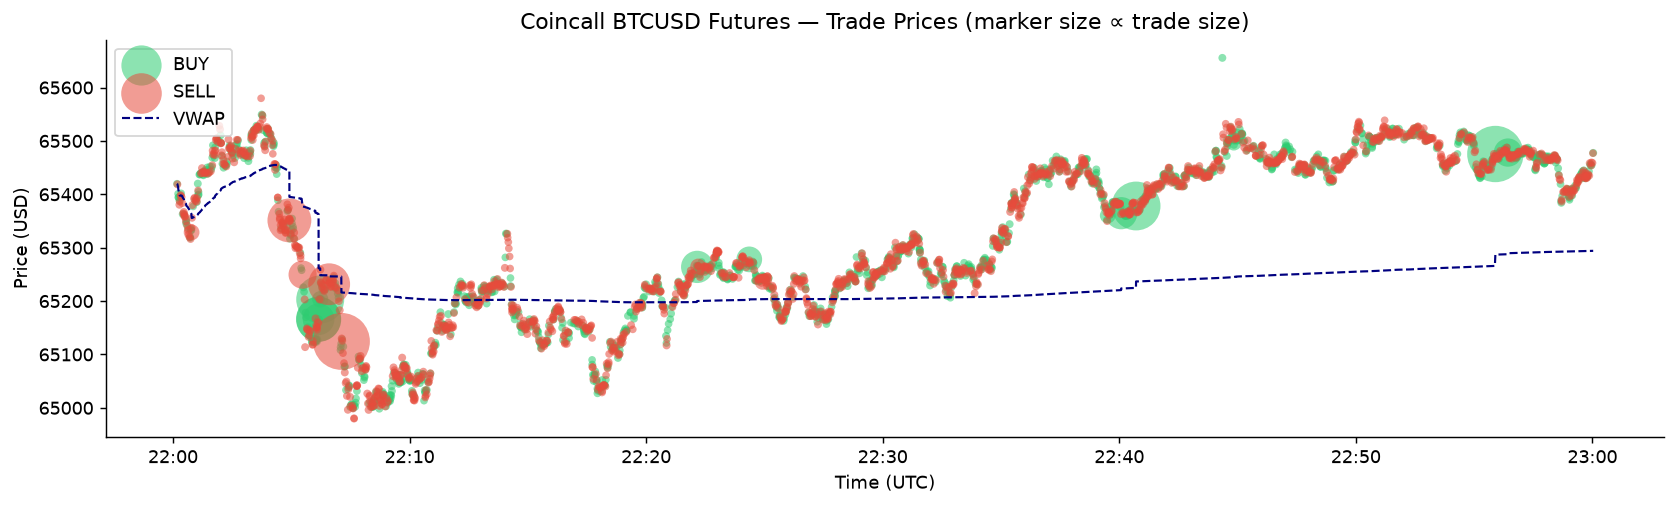

Session VWAP  : $65,294.08
Price return  : +0.088%  (22:00 → 23:00 UTC)


In [14]:
df["cum_pv"] = (df["price"] * df["qty"]).cumsum()
df["cum_v"]  = df["qty"].cumsum()
df["vwap"]   = df["cum_pv"] / df["cum_v"]

buys  = df[df.trade_side == 1]
sells = df[df.trade_side == 2]

fig, ax = plt.subplots(figsize=(13, 4))

# Marker area scaled to trade size; tiny baseline so 0.001 BTC is still visible
def _s(qty): return (qty / df["qty"].median()) ** 0.6 * 18

ax.scatter(buys["ts"],  buys["price"],  s=_s(buys["qty"]),  color=BUY_C,
           alpha=0.55, label="BUY",  zorder=3, linewidths=0)
ax.scatter(sells["ts"], sells["price"], s=_s(sells["qty"]), color=SELL_C,
           alpha=0.55, label="SELL", zorder=3, linewidths=0)
ax.plot(df["ts"], df["vwap"], color="navy", lw=1.2, ls="--", label="VWAP", zorder=4)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Price (USD)")
ax.set_title("Coincall BTCUSD Futures — Trade Prices (marker size ∝ trade size)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "trades_price_timeline.png", dpi=150)
plt.show()

final_vwap    = df["vwap"].iloc[-1]
price_return  = (df["price"].iloc[-1] - df["price"].iloc[0]) / df["price"].iloc[0] * 100
print(f"Session VWAP  : ${final_vwap:,.2f}")
print(f"Price return  : {price_return:+.3f}%  ({t_start.strftime('%H:%M')} → {t_end.strftime('%H:%M')} UTC)")


## 3 · Trade Size Distribution

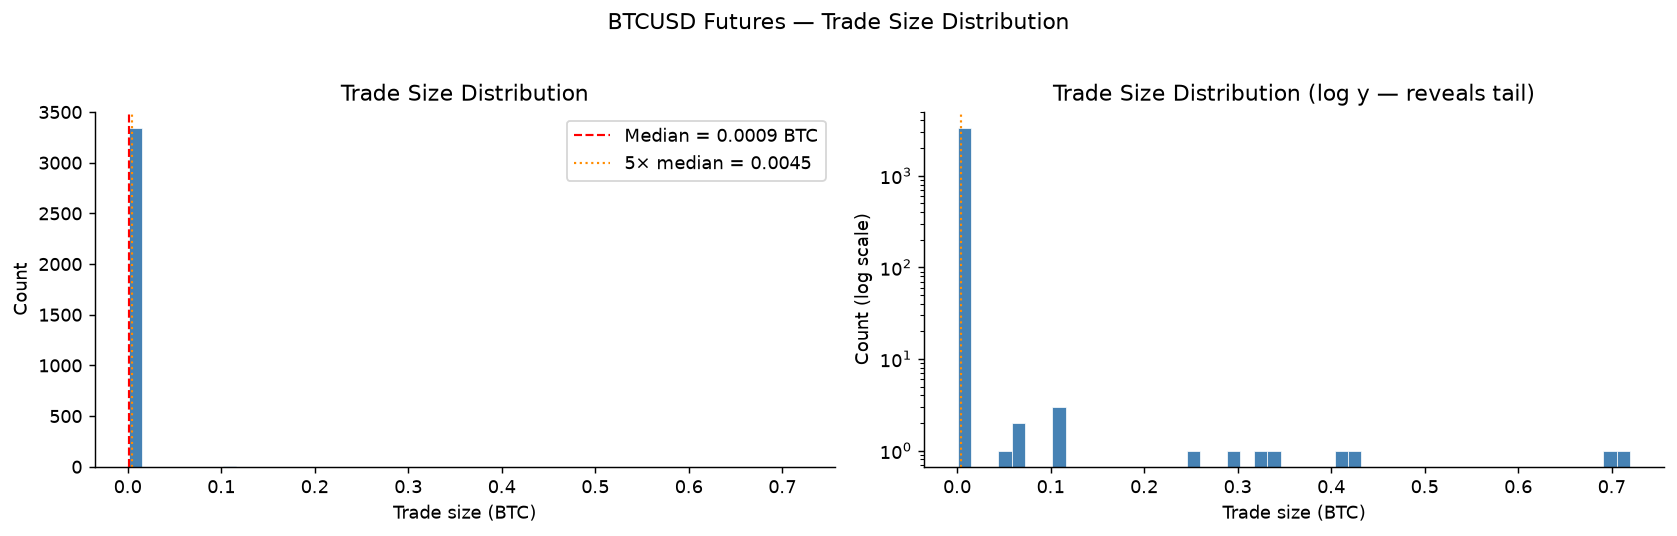

Large trades (> 0.0045 BTC): 22
  ts_str   price   qty side_label
22:00:47 65328.7 0.010       SELL
22:04:55 65351.1 0.302       SELL
22:05:28 65249.5 0.069       SELL
22:06:09 65165.9 0.103        BUY
22:06:09 65165.9 0.322        BUY
22:06:09 65165.9 0.334        BUY
22:06:13 65203.0 0.407        BUY
22:06:13 65203.5 0.011        BUY
22:06:36 65231.5 0.258       SELL
22:07:07 65124.4 0.720       SELL
22:09:36 65054.8 0.009        BUY
22:22:09 65264.0 0.109        BUY
22:22:12 65264.8 0.010       SELL
22:24:21 65278.1 0.051        BUY
22:24:55 65236.0 0.010       SELL
22:39:30 65360.3 0.010        BUY
22:40:04 65364.6 0.108        BUY
22:40:42 65378.1 0.432        BUY
22:44:50 65496.8 0.010        BUY
22:44:56 65508.4 0.010        BUY
22:55:53 65475.5 0.697        BUY
22:56:25 65478.2 0.070        BUY


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

med_qty   = df["qty"].median()
threshold = med_qty * 5

axes[0].hist(df["qty"], bins=50, color=NEU_C, edgecolor="white", lw=0.4)
axes[0].axvline(med_qty, color="red", ls="--", lw=1.2,
                label=f"Median = {med_qty:.4f} BTC")
axes[0].axvline(threshold, color="darkorange", ls=":", lw=1.2,
                label=f"5× median = {threshold:.4f}")
axes[0].set_xlabel("Trade size (BTC)")
axes[0].set_ylabel("Count")
axes[0].set_title("Trade Size Distribution")
axes[0].legend()

axes[1].hist(df["qty"], bins=50, color=NEU_C, edgecolor="white", lw=0.4)
axes[1].set_yscale("log")
axes[1].set_xlabel("Trade size (BTC)")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title("Trade Size Distribution (log y — reveals tail)")
axes[1].axvline(threshold, color="darkorange", ls=":", lw=1.2)

plt.suptitle("BTCUSD Futures — Trade Size Distribution", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "trades_size_dist.png", dpi=150)
plt.show()

large = df[df["qty"] > threshold].copy()
large["ts_str"] = large["ts"].dt.strftime("%H:%M:%S")
print(f"Large trades (> {threshold:.4f} BTC): {len(large)}")
print(large[["ts_str", "price", "qty", "side_label"]].to_string(index=False))


## 4 · Cumulative Volume & Order Flow Imbalance

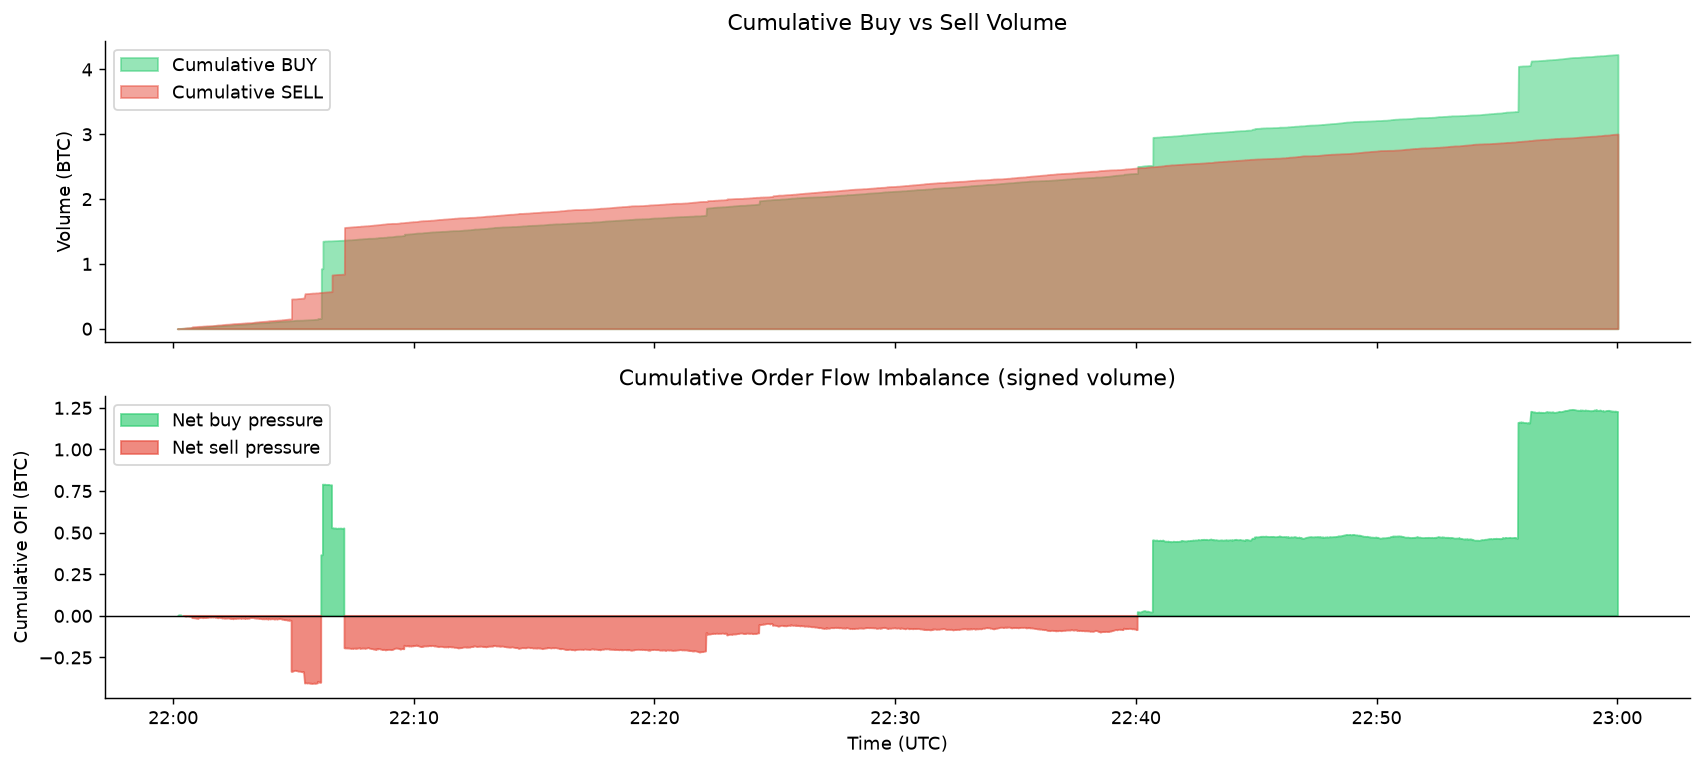

Total BUY  volume : 4.2304 BTC
Total SELL volume : 3.0044 BTC
Net OFI           : +1.2260 BTC  (buy-dominated)


In [16]:
df["cum_buy_v"]  = (df["qty"] * (df.trade_side == 1)).cumsum()
df["cum_sell_v"] = (df["qty"] * (df.trade_side == 2)).cumsum()
cum_ofi = df["signed_qty"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].fill_between(df["ts"], df["cum_buy_v"],  alpha=0.5, color=BUY_C,  label="Cumulative BUY")
axes[0].fill_between(df["ts"], df["cum_sell_v"], alpha=0.5, color=SELL_C, label="Cumulative SELL")
axes[0].set_ylabel("Volume (BTC)")
axes[0].set_title("Cumulative Buy vs Sell Volume")
axes[0].legend()

axes[1].fill_between(df["ts"], cum_ofi, where=(cum_ofi >= 0), color=BUY_C,  alpha=0.65, label="Net buy pressure")
axes[1].fill_between(df["ts"], cum_ofi, where=(cum_ofi <  0), color=SELL_C, alpha=0.65, label="Net sell pressure")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Cumulative OFI (BTC)")
axes[1].set_xlabel("Time (UTC)")
axes[1].set_title("Cumulative Order Flow Imbalance (signed volume)")
axes[1].legend()

axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.savefig(FIG_DIR / "trades_cum_volume.png", dpi=150)
plt.show()

total_buy_v  = df["cum_buy_v"].iloc[-1]
total_sell_v = df["cum_sell_v"].iloc[-1]
net_ofi      = total_buy_v - total_sell_v
print(f"Total BUY  volume : {total_buy_v:.4f} BTC")
print(f"Total SELL volume : {total_sell_v:.4f} BTC")
print(f"Net OFI           : {net_ofi:+.4f} BTC  ({'buy' if net_ofi > 0 else 'sell'}-dominated)")


## 5 · Rolling Order Flow Imbalance

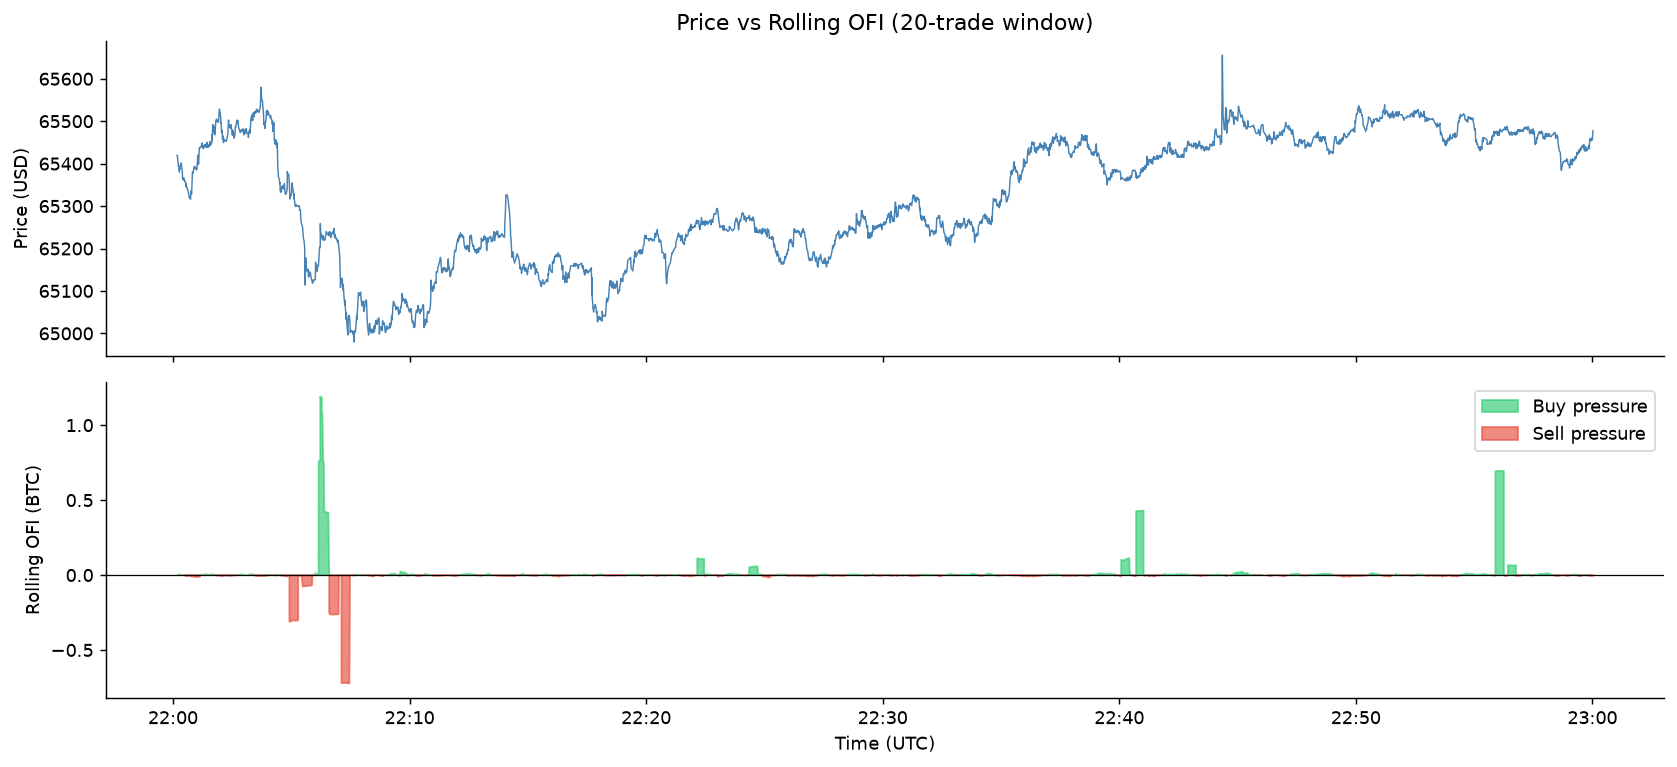

In [17]:
WINDOW = 20

df["roll_ofi"] = df["signed_qty"].rolling(WINDOW, min_periods=1).sum()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(df["ts"], df["price"], color=NEU_C, lw=0.8)
axes[0].set_ylabel("Price (USD)")
axes[0].set_title(f"Price vs Rolling OFI ({WINDOW}-trade window)")

pos = df["roll_ofi"] >= 0
axes[1].fill_between(df["ts"], df["roll_ofi"], where=pos,  color=BUY_C,  alpha=0.65, label="Buy pressure")
axes[1].fill_between(df["ts"], df["roll_ofi"], where=~pos, color=SELL_C, alpha=0.65, label="Sell pressure")
axes[1].axhline(0, color="black", lw=0.7)
axes[1].set_ylabel("Rolling OFI (BTC)")
axes[1].set_xlabel("Time (UTC)")
axes[1].legend()

axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.savefig(FIG_DIR / "trades_rolling_ofi.png", dpi=150)
plt.show()


## 6 · Inter-trade Arrival Times

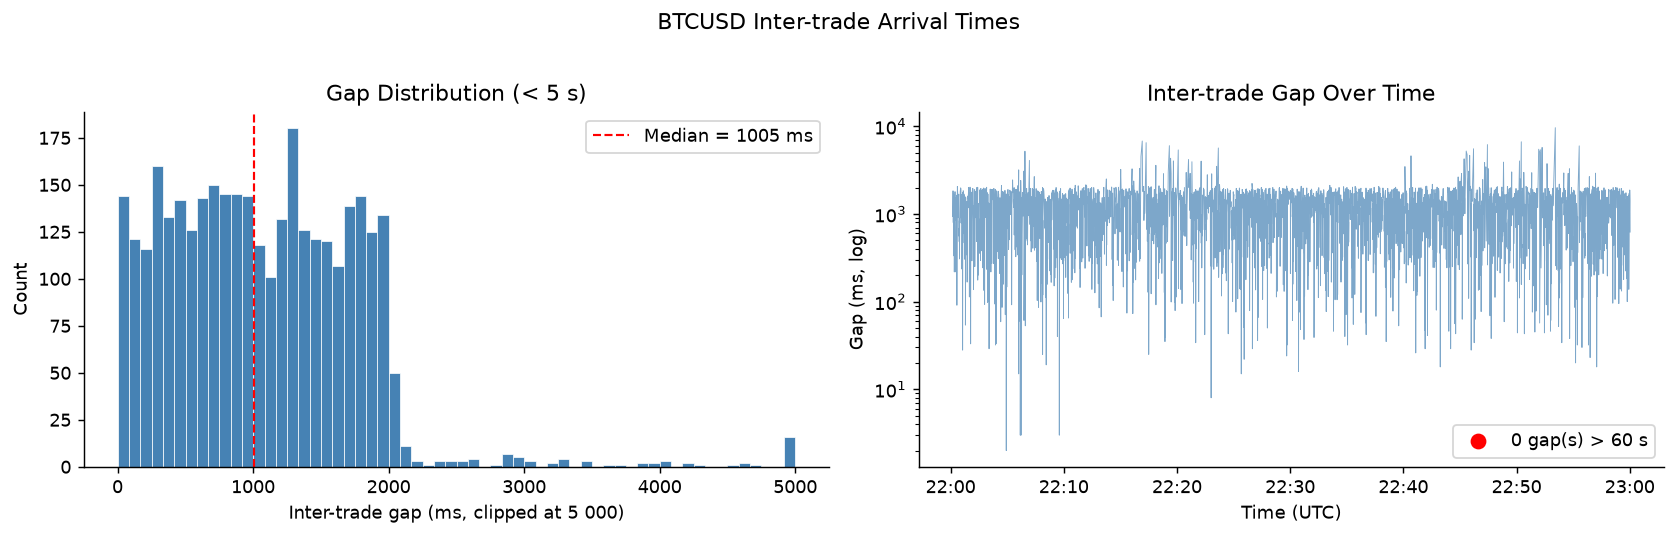

Gap stats (ms):  min=2  p25=518  median=1005  p75=1544  max=9630


In [18]:
gaps = df["dt_ms"].dropna()
big_gaps = df[df["dt_ms"] > 60_000]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gaps.clip(upper=5_000), bins=60, color=NEU_C, edgecolor="white", lw=0.4)
axes[0].axvline(gaps.median(), color="red", ls="--", lw=1.2,
                label=f"Median = {gaps.median():.0f} ms")
axes[0].set_xlabel("Inter-trade gap (ms, clipped at 5 000)")
axes[0].set_ylabel("Count")
axes[0].set_title("Gap Distribution (< 5 s)")
axes[0].legend()

axes[1].semilogy(df["ts"].iloc[1:], gaps, lw=0.5, color=NEU_C, alpha=0.7)
axes[1].scatter(big_gaps["ts"], big_gaps["dt_ms"], color="red", s=60, zorder=5,
                label=f"{len(big_gaps)} gap(s) > 60 s")
axes[1].set_xlabel("Time (UTC)")
axes[1].set_ylabel("Gap (ms, log)")
axes[1].set_title("Inter-trade Gap Over Time")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].legend()

plt.suptitle("BTCUSD Inter-trade Arrival Times", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "trades_gaps.png", dpi=150)
plt.show()

print(f"Gap stats (ms):  min={gaps.min():.0f}  p25={gaps.quantile(.25):.0f}  "
      f"median={gaps.median():.0f}  p75={gaps.quantile(.75):.0f}  max={gaps.max():.0f}")
if len(big_gaps):
    print()
    print("Gaps > 60 s (possible quiet periods or API outages):")
    for _, r in big_gaps.iterrows():
        print(f"  {r['ts'].strftime('%H:%M:%S')} UTC  gap = {r['dt_ms']/1000:.1f} s  "
              f"price before = ${r['price']:,.1f}  side = {r['side_label']}")


## 7 · Trade Activity Rate

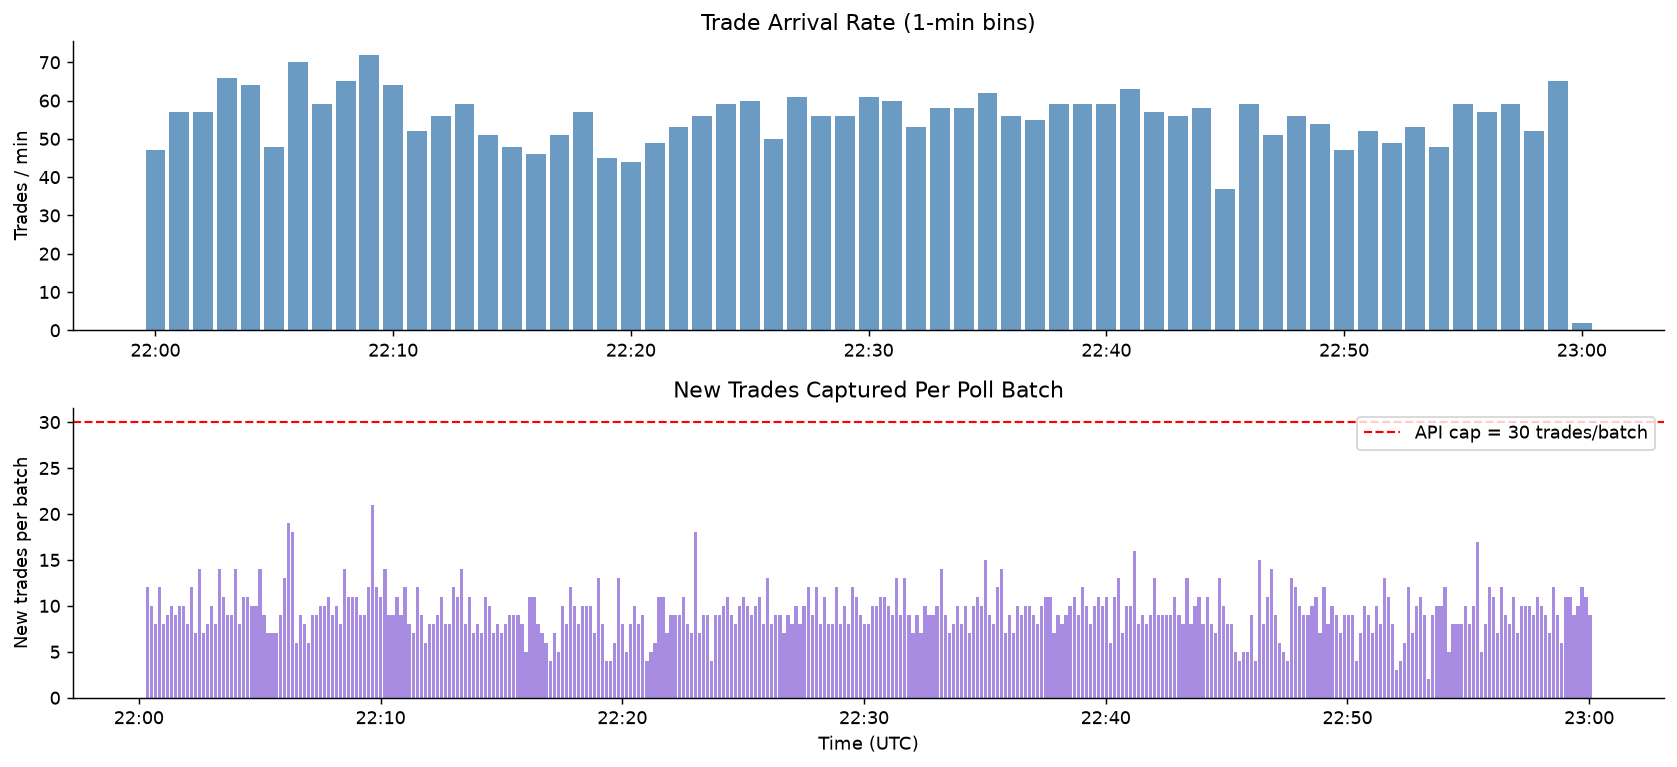

Mean trades/min       : 55.0
Batches at API cap 30 : 0 / 359  (0.0%) — trades may have been missed during these polls


In [19]:
df_rate = df.set_index("ts")["price"].resample("1min").count().rename("trades_per_min")

batch_sizes = (df.groupby("recv_ts_ms").size()
                 .reset_index(name="n")
                 .assign(batch_ts=lambda x: pd.to_datetime(x["recv_ts_ms"], unit="ms", utc=True)))

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)

axes[0].bar(df_rate.index, df_rate.values,
            width=pd.Timedelta("50s"), color=NEU_C, alpha=0.8)
axes[0].set_ylabel("Trades / min")
axes[0].set_title("Trade Arrival Rate (1-min bins)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

axes[1].bar(batch_sizes["batch_ts"], batch_sizes["n"],
            width=pd.Timedelta("8s"), color="mediumpurple", alpha=0.8)
axes[1].axhline(30, color="red", ls="--", lw=1.2, label="API cap = 30 trades/batch")
axes[1].set_ylabel("New trades per batch")
axes[1].set_xlabel("Time (UTC)")
axes[1].set_title("New Trades Captured Per Poll Batch")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "trades_activity_rate.png", dpi=150)
plt.show()

n_at_cap = (batch_sizes["n"] == 30).sum()
print(f"Mean trades/min       : {df_rate.mean():.1f}")
print(f"Batches at API cap 30 : {n_at_cap} / {len(batch_sizes)}  "
      f"({n_at_cap/len(batch_sizes)*100:.1f}%) — trades may have been missed during these polls")


## 8 · Capture Latency (Trade Staleness)

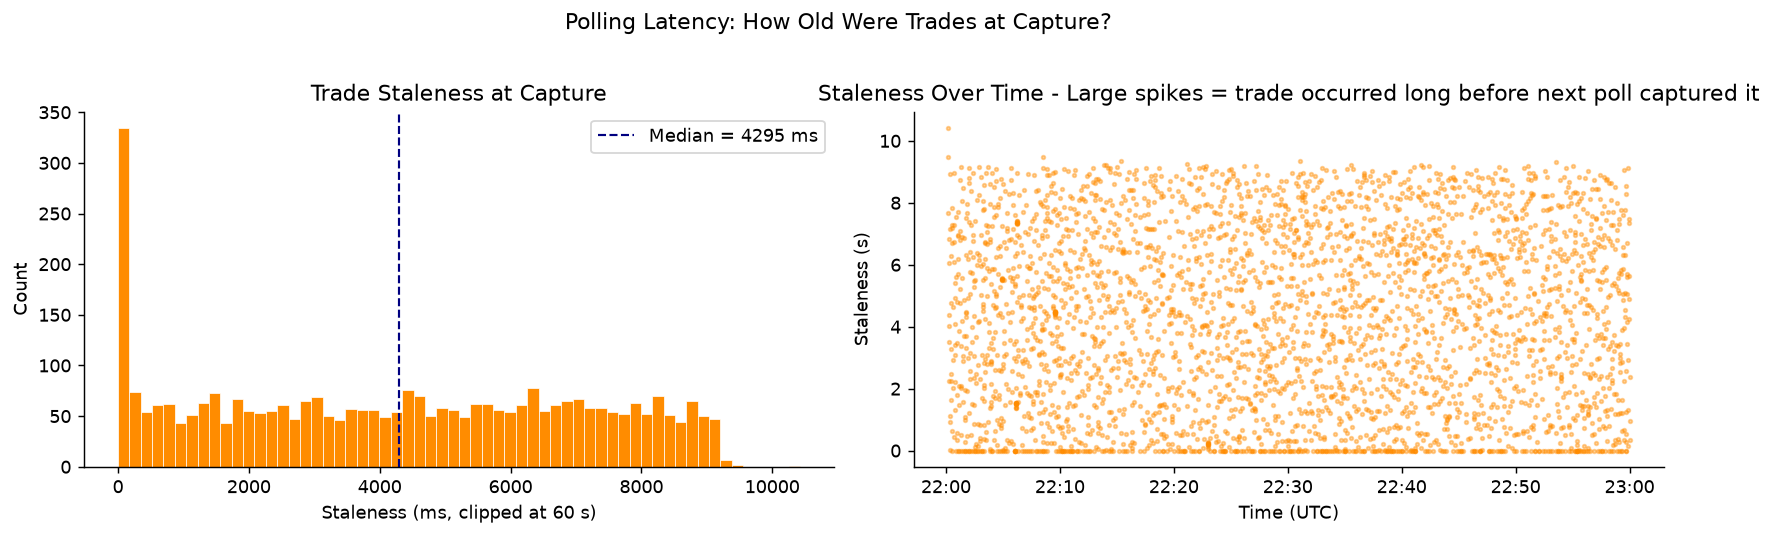

Staleness stats (ms):  median=4295  p90=8178  max=10425

  BUY: median = 4294 ms  mean = 4249 ms
  SELL: median = 4299 ms  mean = 4198 ms


In [20]:
# staleness_ms = recv_ts_ms − trade.time
# = how old was the trade when our poll captured it

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

med_stale = df["staleness_ms"].median()

axes[0].hist(df["staleness_ms"].clip(upper=60_000), bins=60,
             color="darkorange", edgecolor="white", lw=0.4)
axes[0].axvline(med_stale, color="navy", ls="--", lw=1.2,
                label=f"Median = {med_stale:.0f} ms")
axes[0].set_xlabel("Staleness (ms, clipped at 60 s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Trade Staleness at Capture")
axes[0].legend()

axes[1].scatter(df["ts"], df["staleness_ms"] / 1000, s=4, alpha=0.4, color="darkorange")
axes[1].set_xlabel("Time (UTC)")
axes[1].set_ylabel("Staleness (s)")
axes[1].set_title("Staleness Over Time - Large spikes = trade occurred long before next poll captured it")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.suptitle("Polling Latency: How Old Were Trades at Capture?", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "trades_latency.png", dpi=150)
plt.show()

print(f"Staleness stats (ms):  median={med_stale:.0f}  "
      f"p90={df['staleness_ms'].quantile(.9):.0f}  max={df['staleness_ms'].max():.0f}")
print()
for side, label in [(1, "BUY"), (2, "SELL")]:
    sub = df[df.trade_side == side]["staleness_ms"]
    print(f"  {label}: median = {sub.median():.0f} ms  mean = {sub.mean():.0f} ms")


## 9 · Price Impact by Trade Direction

Average forward return (bps) by trade direction:
             k=1    k=3    k=5   k=10   k=20
Direction                                   
BUY        0.011  0.056  0.065  0.117  0.192
SELL      -0.006 -0.037 -0.034 -0.055 -0.072


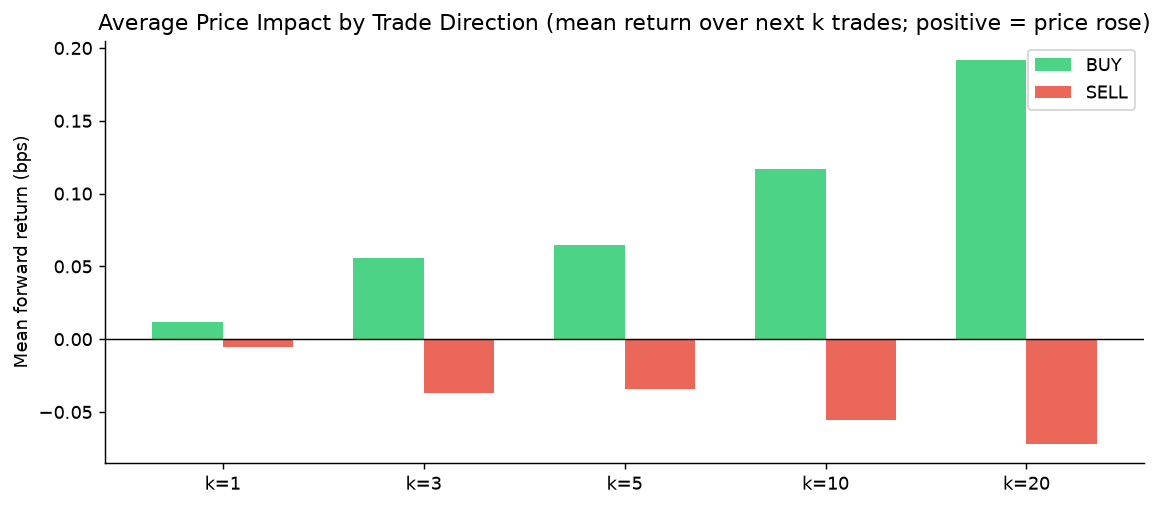

In [21]:
# Average forward return (in bps) over the next k trades, conditioned on direction.
# Positive = price rose after that trade type → consistent with informed buying/selling.

Ks = [1, 3, 5, 10, 20]
for k in Ks:
    df[f"fwd_{k}"] = (df["price"].shift(-k) / df["price"] - 1) * 10_000   # bps

rows = []
for side, label in [(1, "BUY"), (2, "SELL")]:
    sub  = df[df.trade_side == side]
    row  = {"Direction": label}
    for k in Ks:
        row[f"k={k}"] = sub[f"fwd_{k}"].mean()
    rows.append(row)

impact = pd.DataFrame(rows).set_index("Direction")
print("Average forward return (bps) by trade direction:")
print(impact.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(len(Ks))
width = 0.35
ax.bar(x - width/2, impact.loc["BUY"],  width, color=BUY_C,  alpha=0.85, label="BUY")
ax.bar(x + width/2, impact.loc["SELL"], width, color=SELL_C, alpha=0.85, label="SELL")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"k={k}" for k in Ks])
ax.set_ylabel("Mean forward return (bps)")
ax.set_title("Average Price Impact by Trade Direction (mean return over next k trades; positive = price rose)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "trades_price_impact.png", dpi=150)
plt.show()


## 10 · Summary

In [22]:
summary = pd.DataFrame({
    "Metric": [
        "Trades captured",
        "Poll batches",
        "Capture span (min)",
        "Price range (USD)",
        "Session price return (%)",
        "Session VWAP (USD)",
        "BUY count",
        "SELL count",
        "Total BUY volume (BTC)",
        "Total SELL volume (BTC)",
        "Net OFI (BTC)",
        "Median trade size (BTC)",
        "Large trades (> 5× median)",
        "Median inter-trade gap (ms)",
        "Max inter-trade gap (s)",
        "Batches at API cap (30 trades)",
        "Median capture staleness (ms)",
    ],
    "Value": [
        n_trades,
        n_batches,
        round(span_min, 1),
        f"${price_lo:,.1f} – ${price_hi:,.1f}",
        round(price_return, 3),
        round(final_vwap, 2),
        n_buy,
        n_sell,
        round(total_buy_v, 4),
        round(total_sell_v, 4),
        round(net_ofi, 4),
        round(df["qty"].median(), 4),
        len(large),
        round(gaps.median(), 0),
        round(gaps.max() / 1000, 1),
        n_at_cap,
        round(med_stale, 0),
    ],
})
print(summary.to_string(index=False))


                        Metric                 Value
               Trades captured                  3352
                  Poll batches                   359
            Capture span (min)                  59.9
             Price range (USD) $64,979.6 – $65,655.6
      Session price return (%)                 0.088
            Session VWAP (USD)              65294.08
                     BUY count                  1635
                    SELL count                  1717
        Total BUY volume (BTC)                4.2304
       Total SELL volume (BTC)                3.0044
                 Net OFI (BTC)                 1.226
       Median trade size (BTC)                0.0009
    Large trades (> 5× median)                    22
   Median inter-trade gap (ms)                1005.0
       Max inter-trade gap (s)                   9.6
Batches at API cap (30 trades)                     0
 Median capture staleness (ms)                4295.0
